In [1]:
import bs4
import matplotlib
import matplotlib.pyplot as plt
from selenium import webdriver
import selenium
from selenium.webdriver.chrome.options import Options
import time
import re
import html
import statistics

Uporabili bomo knjižico Selenium, saj requests modul ni deloval zaradi IMDb-jeve zaščite

In [2]:
options = Options()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36")
options.add_argument("--headless") # ne pokaže brksalnika


Uporabili bomo modul Beautiful Soup, da lahko lepše analiziramo podatke. Ti podatki bodo vedno posodobljeni, saj se bodo s posodobitvijo spletne strani posodobili tudi naši podatki.

In [3]:
def preveri_st_filmov(url):
    driver = webdriver.Chrome(options=options)
    driver.get(url)
    time.sleep(27) # da se stran naloži
    piskoti = driver.find_element(selenium.webdriver.common.by.By.XPATH, "//html/body/div[2]/div[2]/div/div[2]/div/button[2]")
    piskoti.click()
    
    vsebina = bs4.BeautifulSoup(driver.page_source, 'html.parser')
    filmi = vsebina.find("ul", class_="ipc-metadata-list")
    
    seznam_filmov = filmi.find_all(class_="ipc-metadata-list-summary-item")
    driver.quit()
    return seznam_filmov, len(seznam_filmov)


In [4]:
def iskanje_filmov(zacetno_leto_iskanja, koncno_leto_iskanja, velikost_vzorca, izbrani_zanri):   
    # link do naprednega iskanja filmov (analizirali bomo le filme). Parameter count predstavlja velikost podatkov
    # podatki za zanr bodo oblike https://www.imdb.com/search/title/?title_type=feature&genres=zanr1,zanr2,...
    seznam_moznih_zanrov = ['action', 'adventure', 'animation', 'biography', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'film-noir', 'game-show', 'history', 'horror', 'music', 'musical', 'mystery', 'news', 'reality-tv', 'romance', 'sci-fi', 'sport', 'talk-show', 'thriller', 'war', 'western']
        
    veljaven_izbor = False 
    najdeni_filmi = []

    # preveri ali je izbor zanra veljaven
    while not veljaven_izbor:
        izbrani_zanri.rstrip() # da se izognemo nepotrebnim presledkom na koncu vrstice
        izbrani_zanri = izbrani_zanri.split(",")
        izbrani_zanri = [x.lower() for x in izbrani_zanri]

        if set(izbrani_zanri).issubset(seznam_moznih_zanrov):
            veljaven_izbor = True
            url_izbor = ",".join(izbrani_zanri)
            nov_url = f"https://www.imdb.com/search/title/?title_type=feature&release_date={zacetno_leto_iskanja}-01-01,{koncno_leto_iskanja}-12-31&genres={url_izbor}&count={velikost_vzorca}"
            # rabimo preveriti ali je izbor preozek ali ne
            filmi, st_filmov = preveri_st_filmov(nov_url)
            if st_filmov > 0:
                najdeni_filmi.extend(filmi)
            elif st_filmov == 0:
                print("Izbran nabor je preozek. Poskusi izbrati širši izbor")
                veljaven_izbor = False
            
        else:
            print("To ni veljaven izbor vrste filmov.")
        
        
        return najdeni_filmi, zacetno_leto_iskanja, koncno_leto_iskanja
    # zdaj imamo veljaven nabor žanrov, po kateri lahko naredimo analizo podatkov


Zdaj, ko imamo podakte o filmih, moramo izluščiti podatke o vsakem filmu (naslov, dolžina, leto izdaje, ocena, ...)

In [5]:
#funkcija, ki zapise podatke v datoteko

def zapisi_podatke(zac_leto, kon_leto, velikost_vzorca, vrsta_filmov):
    nas_seznam_filmov, zac_leto, kon_leto = iskanje_filmov(zac_leto, kon_leto, velikost_vzorca, vrsta_filmov)
    podatki_o_filmih = []
    ime_datoteke =  f"Filmi_{vrsta_filmov}_{zac_leto}-{kon_leto}.txt"
    
    for film in nas_seznam_filmov:
        neobdelan_naslov = re.findall(r'<h4 class="ipc-title__text">(.+?)</h4>', film.decode_contents())[0]
        naslov = html.unescape(re.sub(r"\d+. ", "", neobdelan_naslov))
        dodatni_podatki = re.findall(r'<li class="ipc-inline-list__item" role="presentation">(.+?)</li>', film.decode_contents())
        
        # problem je, da nekateri filmi še nimajo določene dolžine
        leto_izida = dodatni_podatki[0]
        try:
            neobdelano_trajanje = re.findall(r"\d+", dodatni_podatki[1])
            try:
                trajanje = int(neobdelano_trajanje[0]) * 60 + int(neobdelano_trajanje[1]) # h * 60 + min
            except IndexError:
                trajanje = int(neobdelano_trajanje[0]) # če imamo samo 1 element imamo samo minute
        except IndexError:
            trajanje = "N/A"
        
        # filmi, ki še niso bili izdani še nimajo ocene
        try:
            ocena = re.findall(r'<span class="ipc-rating-star--rating">(.+?)</span>', film.decode_contents())[0]
        except IndexError:
            ocena = "NE"

        podatki_o_filmih.append([naslov, leto_izida, trajanje, ocena])
    with open(ime_datoteke, "w", encoding="utf-8") as file:
        file.write(f"naslov% leto_izida% trajanje% ocena\n")
        for podatek in podatki_o_filmih:
            file.write(f"{podatek[0]}% {podatek[1]}% {podatek[2]}% {podatek[3]}\n") # uporabimo % ker lahko naslov vsebuje , ali pa ;
  
        

Sestavili smo funkcije, ki bodo obdelale podatke. Zdaj nam ostane samo predstavitev podatkov. Izbral bom več časovnih obdobij (1980-1989, 1990-1999, 2000-2009, 2010-2019, 2020-2026) in filme iz različnih žanrov.

In [6]:
dvojice_letnic = [(1980, 1989), (1990, 1999), (2000, 2009), (2010, 2019), (2020, 2026)]

"""
for i in dvojice_letnic:
    z_l = i[0]
    k_l = i[1]
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="action")
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="animation")
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="family")
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="comedy")
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="romance")
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="horror")
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="drama")
"""
    
# funkcija je zakomentirana, ker je že bila uporabljena


'\nfor i in dvojice_letnic:\n    z_l = i[0]\n    k_l = i[1]\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="action")\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="animation")\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="family")\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="comedy")\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="romance")\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="horror")\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="drama")\n'

Pridobili smo vse podatke. Vsi so zapisani v .txt datoteki in zdaj jih lahko analiziramo.

In [7]:
def ime_izid_trajanje_ocena(datoteka):
    seznam_imen = []
    seznam_ocen = []
    seznam_izidov = []
    seznam_trajanj = []
    with open(datoteka, "r", encoding="utf-8") as datoteka:
        podatki = datoteka.readlines()
    
    for vrstica in podatki[1:]:
        vrstica = vrstica.strip()
        
        if not vrstica:
            continue # preskočimo prazne vrstice
        x = [kos.strip() for kos in vrstica.split("%")] # ker so podatki oblike: "presledek"podatek
    
        ime = x[0]
        leto = x[1]
        trajanje = x[2]
        ocena = x[3]

        if ocena.upper() == "NE":
            continue
        if not leto.isdigit():
            continue
        if not trajanje.isdigit():
            continue
            
        # preverimo ali je ocena številka, če ni filma ne dodamo na sezanm
        try:
            x[3] = re.sub(r'\n', '', x[3])
            seznam_imen.append(ime)
            seznam_ocen.append(float(x[3]))
            seznam_izidov.append(int(x[1]))
            seznam_trajanj.append(int(x[2]))
        except ValueError:
            continue
        
    
    return seznam_imen, seznam_izidov, seznam_trajanj, seznam_ocen   

  
   

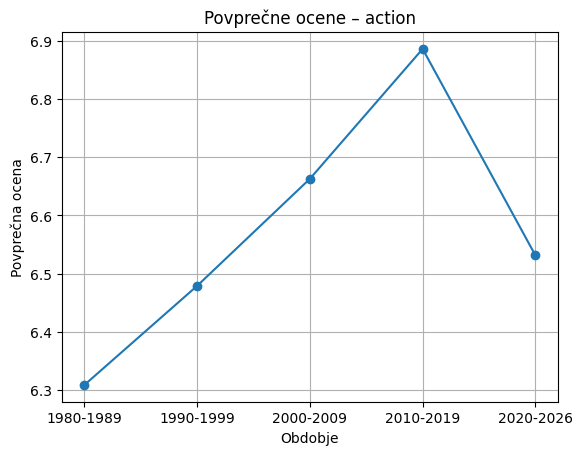

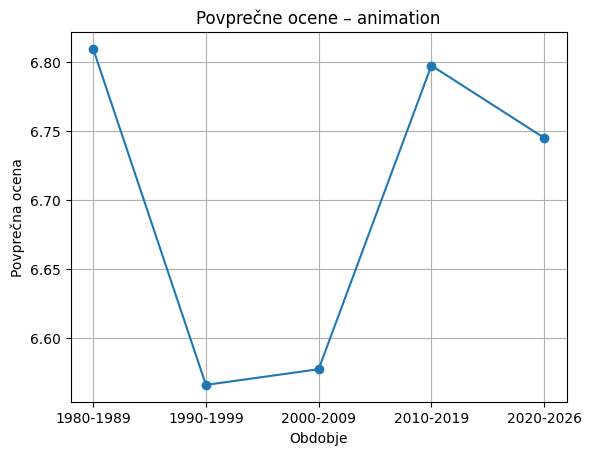

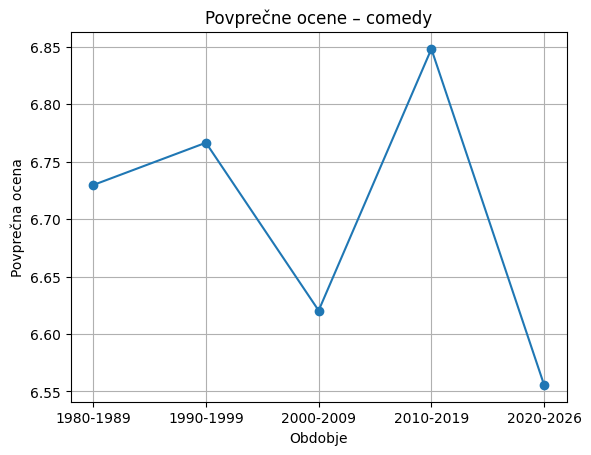

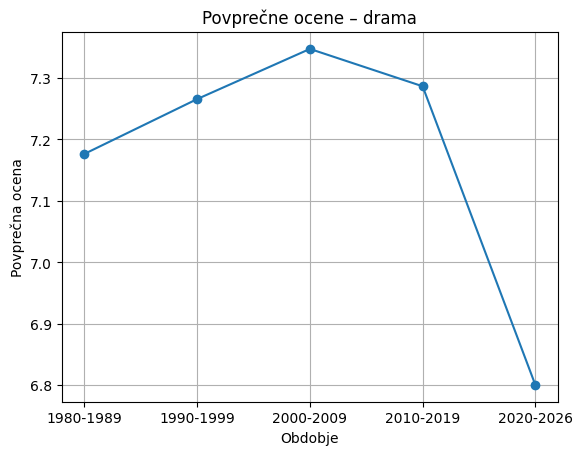

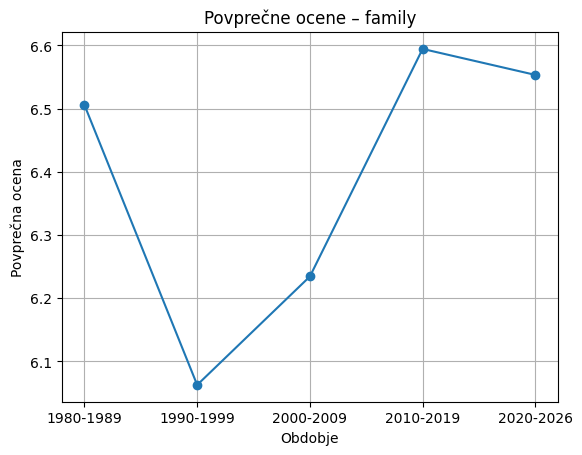

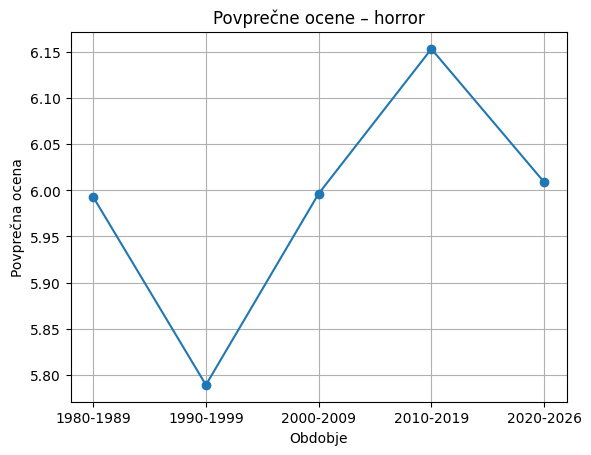

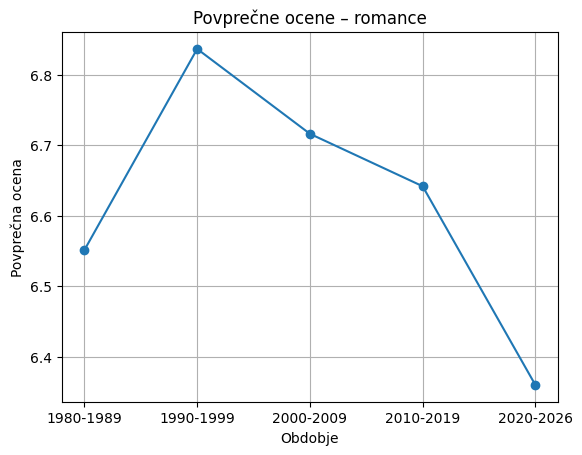

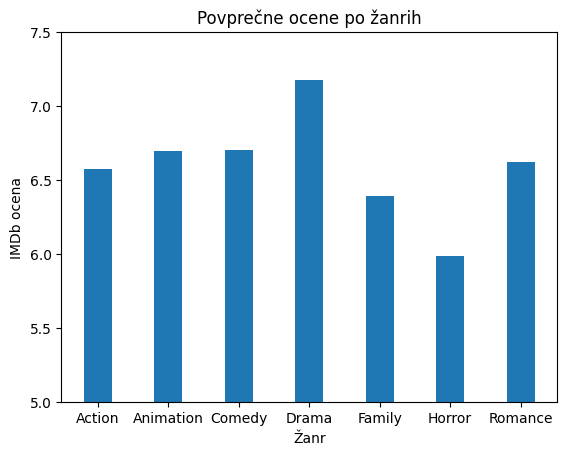

In [17]:
zbrane_vrste_filmov = ["action", "animation", "comedy", "drama", "family", "horror", "romance"]
ocene_filmov = []
# povprečne ocene
for vrsta in zbrane_vrste_filmov:
    povprecne_ocene = []
    obdobja = []
    for k in dvojice_letnic:
        z_l = k[0]
        k_l = k[1]
        obdobje_string = f"{z_l}-{k_l}"
        a, b, c, d = ime_izid_trajanje_ocena(f"Filmi_{vrsta}_{z_l}-{k_l}.txt")
        povprecne_ocene.append(statistics.mean(d))
        obdobja.append(obdobje_string)

    plt.plot(obdobja, povprecne_ocene, marker="o")
    plt.title(f"Povprečne ocene – {vrsta}")
    plt.xlabel("Obdobje")
    plt.ylabel("Povprečna ocena")
    plt.grid(True)
    plt.show()
    ocene_filmov.append(statistics.mean(povprecne_ocene))

# povprečje od 1980-2026 glede na žanr
plt.bar([z.title() for z in zbrane_vrste_filmov ], ocene_filmov, width=0.4)
plt.ylim(5, 7.5)
plt.title("Povprečne ocene po žanrih")
plt.xlabel("Žanr")
plt.ylabel("IMDb ocena")
plt.show()

Vidimo, da so drame z povprečjem 7.18 najvišje ocenjena vrsta filmov, najslabše ocene pa dobivajo grozljivke z povprečjem 5.99 kot prikazuje zadjni graf. Prav tako lahko iz grafov razberemo, da so bili pri večini žanrov (razen pri romantičnih filmih in dramah) najboljši filmi glede na IMDb oceno posneti v obdobju 2010-2019. Romantični filmi pa dobivajo čedalje slabše ocene od odbodbja 1990-1999 naprej. 

Pogledali si bomo, ali je ocena filma povezana z njegovo dolžino.